<span style="color:red"><b><<<<<<< local</b></span>

In [1]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table 

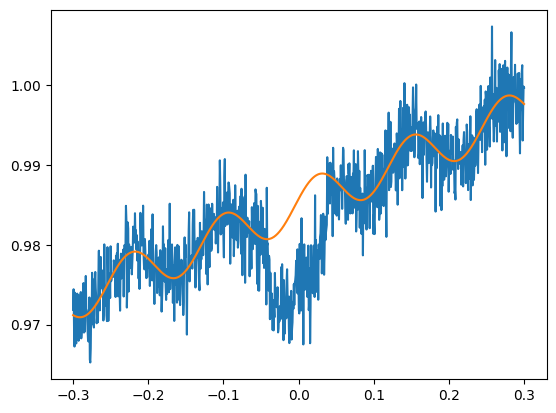

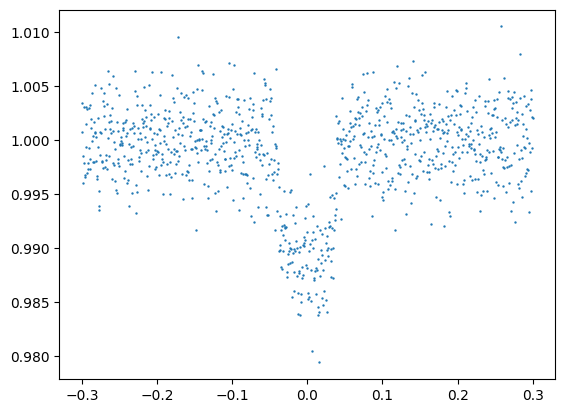

In [ ]:
''' 
    To Groupmates:
        My code isn't fully finished yet, but it works functionally
        here are the variables I created that you guys might need for your part of the code

        x_data -- an array of the raw x_values (Time [Days])
        y_data -- an array of the raw y_values (Flux)
        clean_y -- an array of the cleaned up y_data
        perr -- array of the standard deviation for each parameter from curve_fit

'''

#model that returns a linearlly growing sinusoidal model
def model_test(x,m,b,A,B,C):
    return m*x+b+A*np.sin(B*x + C)

#open the table to extract the data for the x and y values
light_data = Table.read("Planet_Lightcurve.fits")
x_data = light_data["time [days]"]
y_data = light_data["flux"]
    

#Since there seems to be an oscillitory artifact at around x = 0,
#I loop through the x_values and remove any points that fall within -.05 < x < .05
x_sample, y_sample = [],[]
for i in range(len(x_data)):
    if x_data[i] < -.05 or x_data[i] > .05:
        x_sample.append(x_data[i])
        y_sample.append(y_data[i])
    
#initial guesses for the curve_fit function
p0 = [.03,3,.1,-50,-20]
  
popt,pocv = curve_fit(model_test,x_sample,y_sample, sigma=.003, p0=p0)

#array of standard deviations for my best fit values,
perr = np.sqrt(np.diag(pocv))



#divide the artifacts out of the y_data by using the constants found from curve_fit
clean_y = y_data / model_test(x_data,*popt)
    
#create a plot the plots the model over the original data
plt.plot(x_data,y_data)
plt.plot(x_data, model_test(x_data,*popt))
plt.show()

#create a scatterplot of the cleaned up data 
plt.scatter(x_data,clean_y, s=.5)
plt.show()


In [ ]:
# Project - Task 3
# Assigned to Kevin Bozarth

''' 3) Next, using your cleaned-up dataset, have your code come up with an estimate
    for both the depth of the transit in units of relative flux and for its length in days.
    Using the transit depth, you can estimate the radius of the exoplanet using the following equation
    (assume the radius of the star is one solar radii):
    D = (R_planet/R_star)^2
'''

#import numpy as np

time = x_data
flux = clean_y

# Transit depth
baseline = np.median(flux)
transitMin = np.min(flux)
depth = baseline - transitMin

# Identify transit region
threshold = baseline - depth/2
transitMask = flux < threshold # Assigns a bool to transitMask

timeStart = time[transitMask][0]
timeEnd = time[transitMask][-1]
duration = timeEnd - timeStart

# Planet radius
rStar = 1.0 # Solar radii
rPlanet = rStar * np.sqrt(depth)

print(f"Transit depth: {depth}")
print(f"Transit duration (days): {duration}")
print(f"Planet radius (solar radii): {rPlanet}")


<span style="color:red"><b>=======</b></span>

<span style="color:red"><b><<<<<<< local</b></span>

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue May 12 12:08:11 2026

@author: maddyjanebronson
"""
'''
y = m*x+b+A*np.sin(B*x + C)

y = m add rulle *b+ 

y = b + A*np.sin(B*x + C) error add

y = A * (B+C) error multply

y = B + C error add

y = B*x error m
 
y = b + c error add



Using error propagation, 
find out what the root mean squared uncertainty in your measurement of D 
and the transit time is. Don't forget to take into account both the uncertainty 
in the data and the uncertainty from your fits. 
    
then put those values into the og equation
the uncertainity values are from the perr fct above
'''

sigmam = 5.53228901e-04
sigmab = 1.03240464e-04
sigmaA = 1.47250729e-04
sigmaB = 2.89767358e-01
sigmaC = 5.24081955e-02

m = .03
b = 3
A = .1
B = -50
C = -20

sigmaCB = (sigmaB**2 + sigmaC**2)**5

sigmaBA = (sigmaCB/(C+B)) + (sigmaA/A)*(A*sigmaCB)

sigmaAb = (sigmab**2 + sigmaBA**2)**5

sigmafinal = (sigmam**2 + sigmaAb**2)**5

print(f"The Error Propagation for the whole data set is {sigmafinal}")


#error sigmafinal/0.003 that I found via the whole thing above
#errorprop(z) = sigmafinal(/0.003


errorprop = (sigmafinal/(m+b+A*(B+ C))) + (0.003/0.0003) * 0.003

print(f"The given uncertainty divided by the uncertainty found is {errorprop}")

    
'''
this is for the errorprop of D
D = (Rp/Rs)**2

Rp = np.sqrt(D) * Rs
Rp = D^(0.5)
'''

D = depth
Rp = rPlanet
Rs = rStar
sigmad = 0.5*(0.5/D)


print(f"The uncertainty of D is {sigmad}")


<span style="color:red"><b>=======</b></span>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from astropy.table import Table 
from scipy.optimize import curve_fit

# Task 5 (Hudson)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from astropy.table import Table 
from scipy.optimize import curve_fit
from scipy.stats import ttest_ind

plt.rcParams['font.family'] = 'Times New Roman'
plt.rc('font', size = 12)

### Selecting Part of Cleaned Data without Transit 

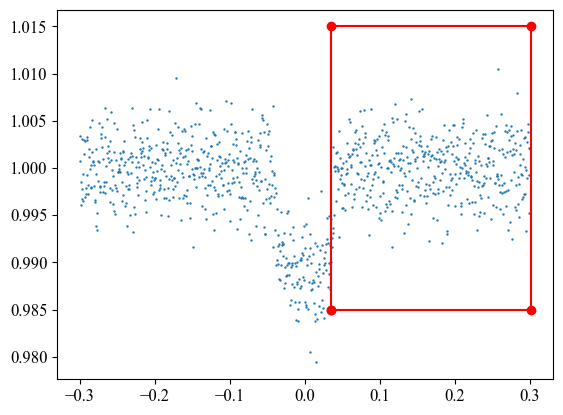

In [7]:
# creating a polygon
x_poly = [0.5*duration, 0.301, 0.301,0.5*duration, 0.5*duration]
y_poly = [0.985, 0.985, 1.015, 1.015, 0.985]
plt.scatter(x_data,clean_y, s=0.5)
plt.plot(x_poly, y_poly, '-o', c='r')

1000


Text(0, 0.5, 'Flux')

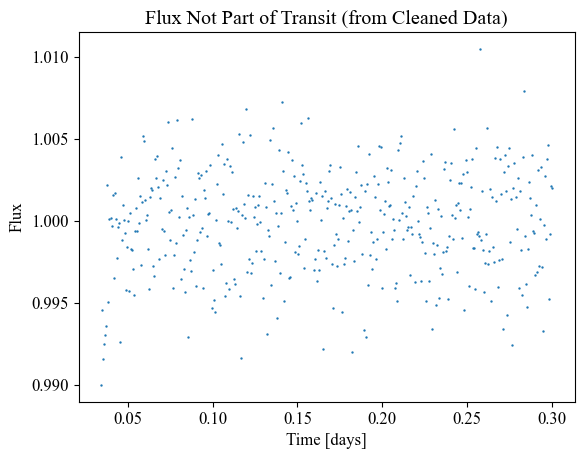

In [8]:
import matplotlib.patches as patches

coords = np.column_stack((x_poly,y_poly))

poly = patches.Polygon(coords)

point_coords = np.column_stack((x_data, clean_y))

is_inpoly = poly.contains_points(point_coords)
#print(is_inpoly)
print(len(is_inpoly))

plt.scatter(x_data[is_inpoly],clean_y[is_inpoly], s=0.5)
plt.title('Flux Not Part of Transit (from Cleaned Data)')
plt.xlabel('Time [days]')
plt.ylabel('Flux')

### Visualizing the Gaussian Distribution of the Cleaned Data

Average flux/brightness observed: 0.9998789903416598
Standard deviation for the flux: 0.030000000000000006


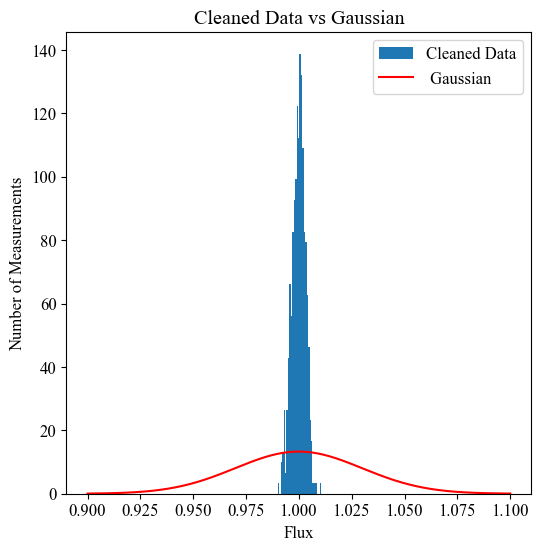

In [9]:
# finding the mean and standard deviation from the cleaned data in polygon
mu = np.mean(clean_y[is_inpoly])
# use sigma after error propogation (task 4)
std = errorprop

print(f'Average flux/brightness observed: {mu}')
print(f'Standard deviation for the flux: {std}')


# creating a function to define a Gaussian 
def gaussian(x, mu, sigma):
    norm = 1/(np.sqrt(2*np.pi*sigma**2)) 

    exponential = np.exp((-1*(x -mu)**2/(2*sigma**2)))

    return norm*exponential

# Plotting the cleaned data as a histogram vs its Gaussian 
# I used plt.scatter rather than plt.plot b/c it represented the Gaussian shape better 
plt.figure(figsize = (6,6))
t = plt.hist(clean_y[is_inpoly], bins = 30, label = 'Cleaned Data', density=True)

xtest = np.linspace(0.9, 1.1, 1000)

plt.plot(xtest, gaussian(xtest, mu, std), c='r', label = ' Gaussian')
plt.xlabel('Flux')
plt.ylabel('Number of Measurements')
plt.title('Cleaned Data vs Gaussian')
plt.legend()
plt.show()


### Creating the Outlier

In [10]:
# creating an outlier with a flux 10% brighter than the mean
outlier = mu*1.1
print(f'Flux of outlier: {outlier}')

# calculating n-sigma of a solar flare 10% brighter than the mean from the cleaned up data 
N_sigma = np.abs((outlier-mu)/std)
print(f'The outlier is a {N_sigma:4.3}-sigma event')


Flux of outlier: 1.0998668893758259
The outlier is a 3.33-sigma event


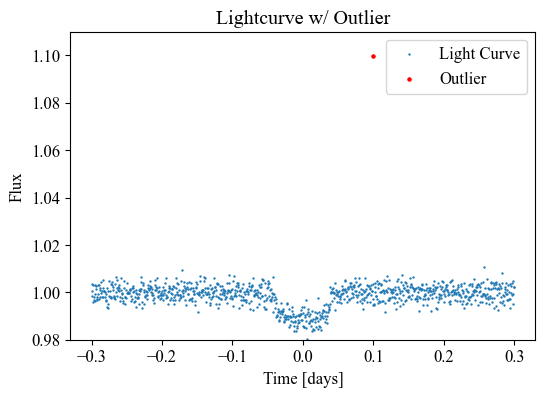

In [12]:
# assigning an arbitrary time (x-value) for the outlier NOT during transit
x_outlier = 0.1

# adding the outlier to the light curve (from Task 2) 
plt.figure(figsize = (6,4))
plt.scatter(x_data,clean_y, s=0.5, label = 'Light Curve')
plt.scatter(x_outlier, outlier, c='r', s = 5, label = 'Outlier')
plt.ylim(0.98, 1.11)
plt.xlabel('Time [days]')
plt.ylabel('Flux')
plt.title('Lightcurve w/ Outlier')
plt.legend()
plt.show()

### Calculating the Statistical Significance of the Outlier 

In [13]:

def solar_flare_prob(x, mu, std):
    '''
    inputs:
        x: solar flare magnitude 
        mu: expected mean from clean data 
        std: expected standard deviation of the Gaussian
    '''
  
    z = np.abs((x-mu)/std)

    prob_upper = 0.5*(1.0 + erf(z/np.sqrt(2)))
    prob_lower = 0.5*(1.0 + erf(-1*z/np.sqrt(2)))

    prob_inside = (prob_upper - prob_lower)

    prob_outside = 1.0 - prob_inside

    return prob_outside 



In [14]:
# declaring probability of outlier 
prob = solar_flare_prob(outlier, mu, std)
print(prob)

print(f'The probability of a solar flare of flux {outlier} is {prob*100:5.3}%.')

0.0008593657075461891
The probability of a solar flare of flux 1.0998668893758259 is 0.0859%.


In [15]:
def chauvenet_criterion(clean_data, outlier):
    '''
    inputs:
        clean_data: array containing the original cleaned-up data set
        outlier: float, 10% brighter outlier along lightcurve where the transit isn't taking place

    returns: 
        keep: boolean, True if we can reject the null hypothesis, False if we can't reject the null hypothesis
    '''
    mu_prior = np.mean(clean_data)
    std_prior = np.std(clean_data)
    outlier_prob = solar_flare_prob(N_sigma, mu_prior, std_prior)

    N = len(clean_data) + 1
    product = N*outlier_prob

    # represents Chauvenet's Criterion 
    # if True, we CAN reject the null hypothesis
    if product < 0.5 and outlier_prob < 1/(2*N):
        reject = True
        return reject
    # if False, CANNOT reject the null hypothesis 
    else:
        reject = False
        return reject

In [16]:
chauvenet = chauvenet_criterion(clean_y[is_inpoly], outlier)
print(f'We can reject the null hypotheis: {chauvenet}')

We can reject the null hypotheis: True


<span style="color:red"><b>>>>>>>> remote</b></span>

<span style="color:red"><b>>>>>>>> remote</b></span>